<a href="https://colab.research.google.com/github/Vojta1999/Programovani1/blob/master/Text_analytics_week4_exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4
# Vector space, Clustering, Dimensionality reduction

## Download resources
- NLTK resources
- Recipe dataset. Source: https://huggingface.co/datasets/corbt/all-recipes

In [1]:
import nltk

# Download required NLTK resources
nltk.download("stopwords")
nltk.download('wordnet')  # lemmatization
nltk.download('omw-1.4')  # lemmatization
nltk.download('punkt_tab')  # tokenizer module

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the dataset
dataset = load_dataset('corbt/all-recipes')
df = pd.DataFrame(dataset['train'])

In [ ]:
df.head()

,input
0,No-Bake Nut Cookies\n\nIngredients:\n- 1 c. fi...
1,Jewell Ball'S Chicken\n\nIngredients:\n- 1 sma...
2,Creamy Corn\n\nIngredients:\n- 2 (16 oz.) pkg....
3,Chicken Funny\n\nIngredients:\n- 1 large whole...
4,Reeses Cups(Candy) \n\nIngredients:\n- 1 c. p...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2147248 entries, 0 to 2147247
Data columns (total 1 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   input   object
dtypes: object(1)
memory usage: 16.4+ MB


Sample random subset from the dataset for faster computation.

In [ ]:
# sample 1% of the data
df = df.sample(frac=0.01, random_state=42)

In [ ]:
df

,input
450189,Greek Salad\n\nIngredients:\n- tomatoes\n- oli...
1290523,Baking Pumpkin For Recipes \n\nIngredients:\n-...
1998670,Apple Crisp\n\nIngredients:\n- 6 -8 medium bak...
1359970,Chocolate Fig And Ginger Fruit Mince\n\nIngred...
1303506,Ratatouille-Like Stew W/ Poached Eggs \n\nIngr...
...,...
74262,Best Ever Oatmeal Cookies\n\nIngredients:\n- 2...
1968063,Citrus-Almond Poundcake\n\nIngredients:\n- 12 ...
766062,Irene'S Mayonnaise Cake\n\nIngredients:\n- 2 c...
1638412,Tangy Thyme Fish\n\nIngredients:\n- 1 lb salmo...


## Preprocess the dataset for TF-IDF DTM creation
Preprocessing function from the Lab 3.

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text)
    # Lowercasing
    tokens = [token.lower() for token in tokens]
    # Remove stop words and non-alphabetic tokens
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

In [ ]:
df['preprocessed_text'] = df['input'].apply(preprocess_text)

Explore the most frequent tokens to unveil more stopwords.

In [ ]:
from collections import Counter

token_counts = Counter()
for text in df['preprocessed_text']:
    token_counts.update(text)
token_counts.most_common(30)

[('cup', 37614),
 ('ingredient', 28712),
 ('add', 24423),
 ('minute', 22555),
 ('direction', 22149),
 ('salt', 19572),
 ('sugar', 18362),
 ('teaspoon', 18255),
 ('pepper', 16680),
 ('tablespoon', 16047),
 ('butter', 14191),
 ('cheese', 13865),
 ('onion', 13855),
 ('chopped', 13782),
 ('heat', 13763),
 ('egg', 13642),
 ('mix', 13574),
 ('tsp', 13280),
 ('oil', 12882),
 ('water', 12404),
 ('cream', 11651),
 ('flour', 11411),
 ('large', 10925),
 ('chicken', 10566),
 ('pan', 10312),
 ('stir', 9949),
 ('cook', 9909),
 ('bowl', 9706),
 ('sauce', 9706),
 ('mixture', 9608)]

In [ ]:
# extend stop_words with new tokens
stop_words_extension = ['cup', 'ingredient', 'add', 'minute', 'direction', 'teaspoon', 'tablespoon', 'heat', \
                        'mix', 'tsp', 'large', 'cook', 'mixture', 'ounce', 'tbsp', 'lb', 'pkg', 'oz', 'slice', \
                        'ml', 'grm']
stop_words.update(stop_words_extension)
# remove these stop words from processed texts
df['preprocessed_text'] = df['preprocessed_text'].apply(lambda x: [word for word in x if word not in stop_words])

In [ ]:
df['preprocessed_text']

,preprocessed_text
450189,"[greek, salad, tomato, olive, oil, caper, feta..."
1290523,"[baking, pumpkin, recipe, pie, pumpkin, cut, h..."
1998670,"[apple, crisp, medium, baking, apple, tart, su..."
1359970,"[chocolate, fig, ginger, fruit, mince, finely,..."
1303506,"[stew, poached, egg, medium, onion, halved, th..."
...,...
74262,"[best, ever, oatmeal, cooky, brown, sugar, sug..."
1968063,"[poundcake, stick, cold, unsalted, butter, cub..."
766062,"[irene, mayonnaise, cake, flour, sugar, mayonn..."
1638412,"[tangy, thyme, fish, salmon, fillet, inch, thi..."


## TF-IDF vectorization

In [ ]:
# create TF-IDF document-term matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the list of tokens into strings for TfidfVectorizer
df['text_for_tfidf'] = df['preprocessed_text'].apply(lambda x: ' '.join(x))

# Initialize and fit the vectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_for_tfidf'])

# Display the shape of the resulting matrix
print(f"TF-IDF Matrix shape: {tfidf_matrix.shape}")

TF-IDF Matrix shape: (21472, 14365)


> **What is the dimmension of the vector space?**

## k-means clustering

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
# Applying KMeans with a chosen k
k = 100
model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=1, random_state=42)
model.fit(tfidf_matrix)

# Assign clusters to the dataframe
df['cluster'] = model.labels_

print(f"Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()
for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}:"),
    print(", ".join(top_terms))
    print()

Top terms per cluster:
Cluster 0:
fish, fillet, pepper, oil, lemon, sauce, salt, juice, garlic, chopped

Cluster 1:
bean, onion, green, pepper, chopped, garlic, water, tomato, kidney, salt

Cluster 2:
roll, crescent, cheese, cream, dough, spread, sheet, bake, rectangle, sugar

Cluster 3:
spaghetti, cheese, sauce, parmesan, mozzarella, lasagna, noodle, tomato, beef, meat

Cluster 4:
lemon, juice, sugar, egg, zest, rind, flour, butter, cake, beat

Cluster 5:
water, salt, butter, egg, sugar, oil, cream, milk, pepper, place

Cluster 6:
cheese, cream, cheddar, pepper, chopped, onion, ball, sauce, grated, shredded

Cluster 7:
syrup, popcorn, corn, sugar, popped, vanilla, butter, caramel, stir, white

Cluster 8:
bacon, onion, pepper, potato, crisp, chopped, cheese, dripping, egg, salt

Cluster 9:
cranberry, orange, sugar, juice, sauce, pineapple, apple, water, chopped, nut

Cluster 10:
jello, pineapple, whip, water, cool, crushed, salad, boiling, cream, cheese

Cluster 11:
chicken, soup, crea

> **How would you name clusters if you needed chapter names for the recipe books? Try naming random 5.**

In [ ]:
# Show a sample of recipes and their assigned clusters
display(df[['input', 'cluster']].head(10))

,input,cluster
450189,Greek Salad\n\nIngredients:\n- tomatoes\n- oli...,54
1290523,Baking Pumpkin For Recipes \n\nIngredients:\n-...,72
1998670,Apple Crisp\n\nIngredients:\n- 6 -8 medium bak...,52
1359970,Chocolate Fig And Ginger Fruit Mince\n\nIngred...,5
1303506,Ratatouille-Like Stew W/ Poached Eggs \n\nIngr...,70
1343535,Ginger Sesame Bok Choy With Shiitake Mushrooms...,35
1454418,Spicy Chicken And Hominy Soup\n\nIngredients:\...,67
1645869,Cheesy Broccoli Rice & Chicken\n\nIngredients:...,60
2073117,Black Bean and Mango Rice Salad\n\nIngredients...,1
465742,Overnight Salad\n\nIngredients:\n- 1 head lett...,18


Plot topic representations using Word Clouds.

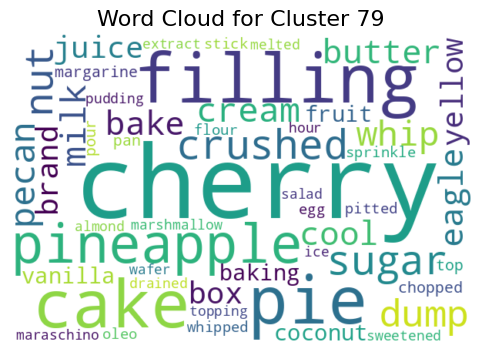

************************************************************************************************************************



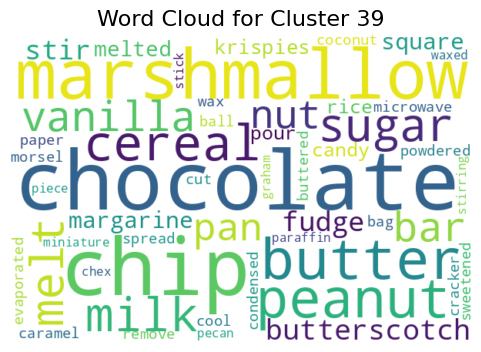

************************************************************************************************************************



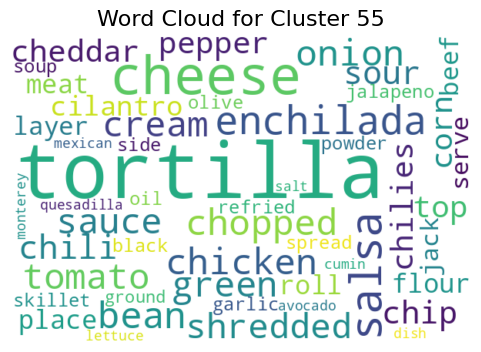

************************************************************************************************************************



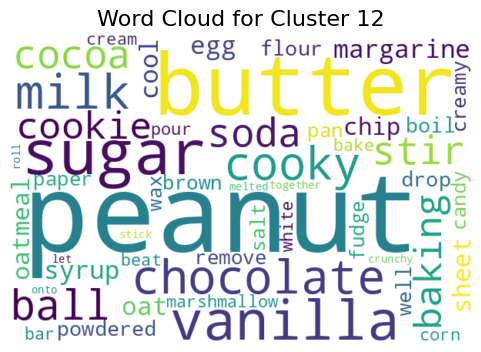

************************************************************************************************************************



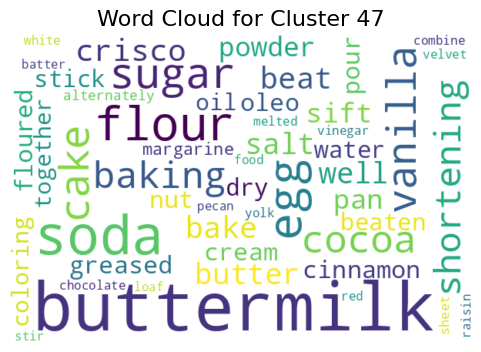

************************************************************************************************************************



In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# Get feature names from the vectorizer
terms = tfidf_vectorizer.get_feature_names_out()

# Pick 5 random cluster indices
random_clusters = random.sample(range(k), 5)

for i in random_clusters:
    # Create a dictionary of words and their importance (cluster center values)
    word_importance = {terms[ind]: model.cluster_centers_[i][ind] for ind in order_centroids[i, :50]}

    # Generate word cloud
    wc = WordCloud(background_color='white', width=600, height=400).generate_from_frequencies(word_importance)

    # Create a separate figure for each cluster
    plt.figure(figsize=(7, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Word Cloud for Cluster {i}', fontsize=16)
    plt.axis('off')
    plt.show()

    print("*" * 120, end='\n\n')

## Dimensionality reduction

- pick 5 random clusters
- reduce dimensionality to 3 dimensions using PCA
- visualize clusters in 3D

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

# Filter the dataframe for the 5 random clusters selected earlier
mask = df['cluster'].isin(random_clusters)
# Convert mask to numpy array to avoid the scipy/pandas indexing conflict
filtered_tfidf = tfidf_matrix[mask.values]

# Reduce dimensionality to 3D for just these clusters
pca = PCA(n_components=3, random_state=42)
pca_results = pca.fit_transform(filtered_tfidf.toarray())

# Create a temporary dataframe for plotting
plot_df = pd.DataFrame(
    pca_results,
    columns=['PC1', 'PC2', 'PC3']
)
plot_df['cluster'] = df[mask]['cluster'].astype(str).values
plot_df['recipe_name'] = df[mask]['input'].apply(lambda x: x.split('\n')[0]).values

# Plot using Plotly with discrete colors
fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='cluster',
    hover_data=['recipe_name'],
    title=f'3D PCA of Clusters: {random_clusters}',
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### Task 1

Reduce dimmensionality to 2 dimensions and
- study wether clusters are separated well in the vector space,
- compare the 2D transformation with 3D transformation,
- try to rotate 3D transformation plot to resemble the 2D transformation.

In [ ]:
# TODO: write your code here

## Hierarchical Clustering (Agglomerative)

In [ ]:
import numpy as np

import plotly.figure_factory as ff
from scipy.cluster.hierarchy import linkage

# Sample a small subset for the dendrogram to maintain readability
dendro_sample_size = 50
np.random.seed(40)
sampled_indices = np.random.choice(tfidf_matrix.shape[0], dendro_sample_size, replace=False)
sampled_matrix = tfidf_matrix[sampled_indices].toarray()

# Perform hierarchical clustering using Ward linkage
linked = linkage(sampled_matrix, method='ward')

# Get recipe names for labels
labels = df.iloc[sampled_indices]['input'].apply(lambda x: x.split('\n')[0][:30]).values

# Create dendrogram using Plotly
fig = ff.create_dendrogram(sampled_matrix, orientation='left', labels=labels)
fig.update_layout(width=800, height=1000, title='Hierarchical Clustering Dendrogram (Subset of 50 recipes)')
fig.show()

### Task 2

- Pick any cluster from the k-means clustering (cluster numbers are assigned in the dataframe)
- Pick a subset of documents from that cluster (e.g. 50) for better interpretation
- Perform Agglomerative Hierarchical Clustering on these documents
- Plot a dendrogram
- Study and evaluate merging process

In [ ]:
# TODO: write your code here